In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.environ["OMP_NUM_THREADS"] = "4"
np.random.seed(42)

PROJECT_ROOT_DIR = "."
CHAPTER_ID = "clustering"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)


def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Clustering


In [2]:
from sklearn.datasets import load_iris

In [3]:
data = load_iris()

X = data.data
y = data.target
print("Target Names")
print(data.target_names)
print("\n\n Feature Names")
print(data.feature_names)

Target Names
['setosa' 'versicolor' 'virginica']


 Feature Names
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Saving figure classification_vs_clustering


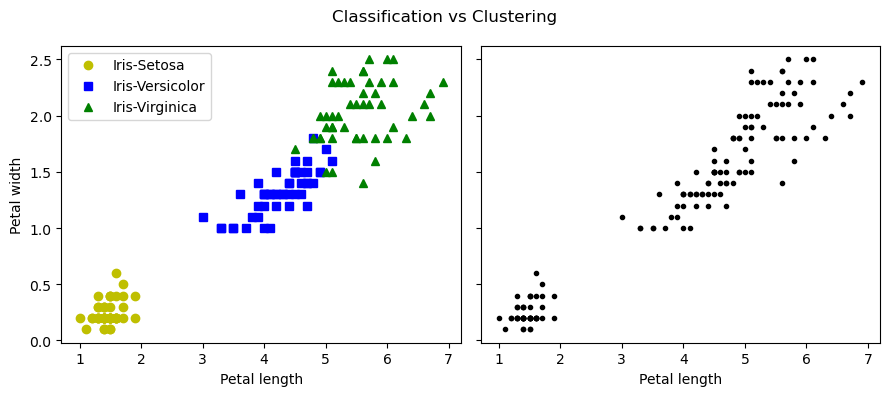

In [4]:
plt.figure(figsize=(9, 4))

plt.subplot(121)
plt.plot(X[y == 0, 2], X[y == 0, 3], "yo", label="Iris-Setosa")
plt.plot(X[y == 1, 2], X[y == 1, 3], "bs", label="Iris-Versicolor")
plt.plot(X[y == 2, 2], X[y == 2, 3], "g^", label="Iris-Virginica")
plt.ylabel("Petal width")
plt.xlabel("Petal length")
plt.legend()

plt.subplot(122)
plt.plot(X[:, 2], X[:, 3], "k.")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)

plt.suptitle("Classification vs Clustering")
save_fig("classification_vs_clustering")
plt.show()

In [5]:
from sklearn.mixture import GaussianMixture
from scipy.stats import mode

In [6]:
y_pred = GaussianMixture(n_components=3).fit_predict(X)

# Map the outputs to the real label
mapping = {}
for class_label in np.unique(y):
    result = mode(y_pred[y == class_label])
    mapping[result.mode.item()] = class_label

y_pred_mapped = np.array([mapping[label] for label in y_pred])

c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


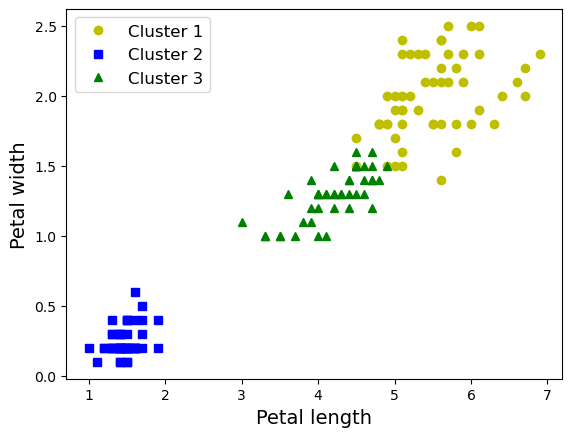

In [7]:
plt.plot(X[y_pred == 0, 2], X[y_pred == 0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred == 1, 2], X[y_pred == 1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred == 2, 2], X[y_pred == 2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.show()

In [8]:
np.sum(y_pred_mapped == y) / len(y_pred)

np.float64(0.9666666666666667)

## K-Means


In [9]:
from sklearn.datasets import make_blobs

In [10]:
blob_centers = np.array(
    [[0.2, 2.3], [-1.5, 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]]
)
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std)

In [11]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$X_1$")
    plt.xlabel("$X_2$", rotation=0)

Saving figure blobs_plot


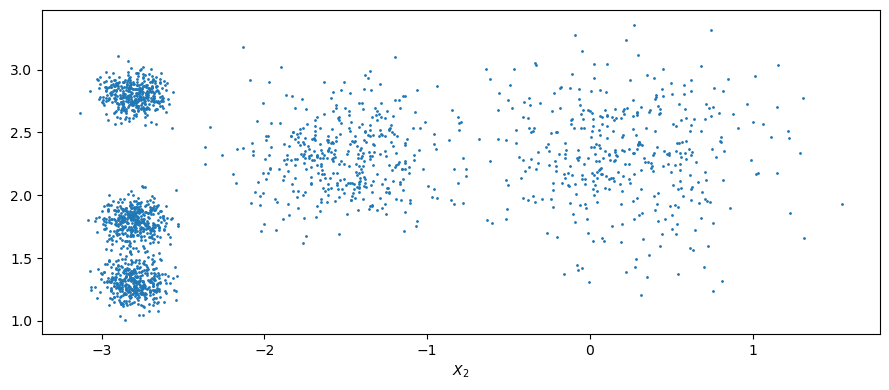

In [12]:
plt.figure(figsize=(9, 4))
plot_clusters(X)
save_fig("blobs_plot")
plt.show()

In [13]:
from sklearn.cluster import KMeans

In [14]:
kmeans = KMeans(n_clusters=5)
y_pred = kmeans.fit_predict(X)

In [15]:
y_pred

array([0, 3, 0, ..., 0, 2, 0], shape=(2000,), dtype=int32)

In [16]:
kmeans.cluster_centers_

array([[-2.80064631,  1.30437745],
       [ 0.21827884,  2.32036728],
       [-2.7940343 ,  2.79617377],
       [-1.48685753,  2.30622178],
       [-2.79228793,  1.7978682 ]])

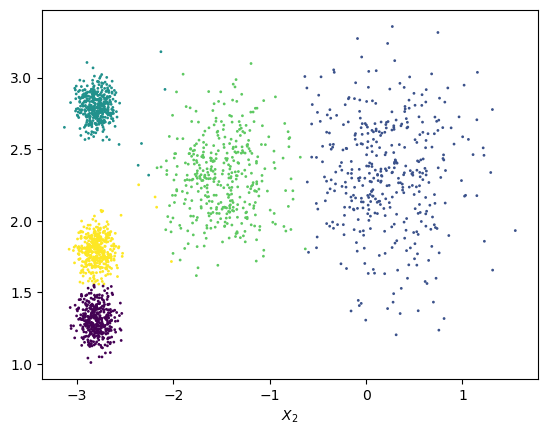

In [17]:
plot_clusters(X, y_pred)

In [18]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], "k.", markersize=2)


def plot_centroids(centroids, circle_color="w", cross_color="k"):
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="o",
        s=35,
        linewidths=8,
        color=circle_color,
        zorder=10,
        alpha=0.9,
    )
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=2,
        linewidths=12,
        color=cross_color,
        zorder=11,
        alpha=1,
    )


def plot_decision_boundary(
    clusterer,
    X,
    resolution=1000,
    show_centroids=True,
    show_xlabels=True,
    show_ylabels=True,
):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1

    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution),
    )
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(
        Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors="k"
    )
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)

    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

Saving figure vronoi_plot


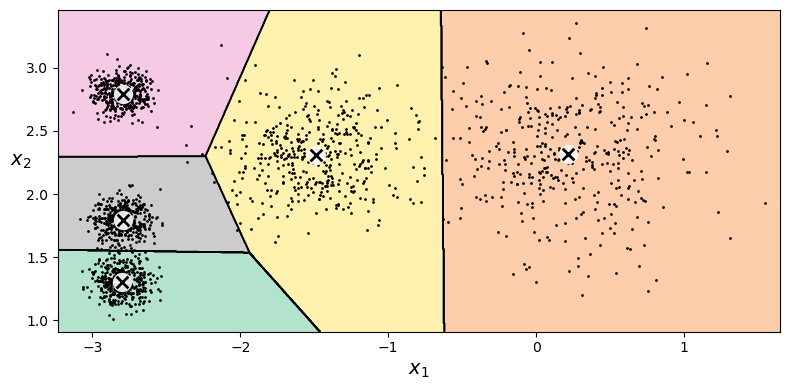

In [19]:
plt.figure(figsize=(8, 4))
plot_decision_boundary(kmeans, X)
save_fig("vronoi_plot")
plt.show()

**Hard Clustering vs Soft Clustering**


Rather than arbitrarily choosing the closest cluster for each instance, which is called hard clustering, it might be better measure the distance of each instance to all 5 centroids. This is what the transform() method does:


In [20]:
X_new = [[0, 2], [3, 2], [-3, 3], [-3, 2.5]]
kmeans.transform(X_new)

array([[2.88574262, 0.38766074, 2.90525736, 1.5180636 , 2.79959446],
       [5.84220748, 2.80010853, 5.84848067, 4.49729499, 5.79581372],
       [1.7073013 , 3.28925817, 0.2897706 , 1.66461057, 1.21994474],
       [1.21212836, 3.22328817, 0.36075029, 1.52549996, 0.73221129]])

### The K-Means Algorithm


Saving figure progression_of_centroids


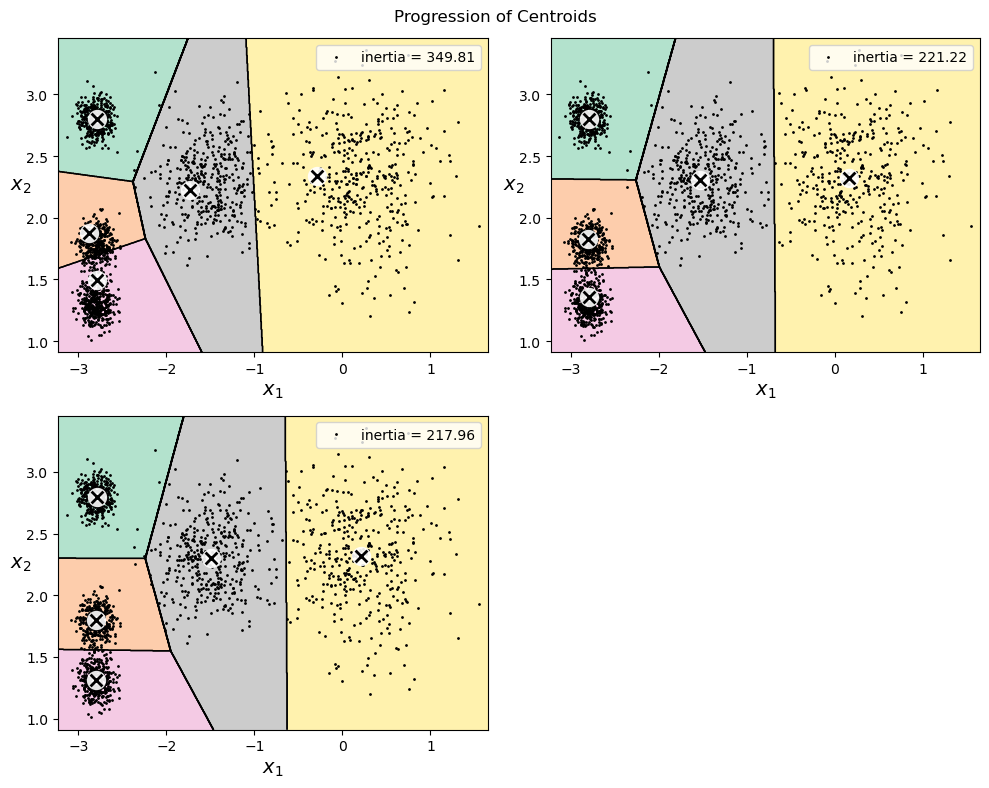

In [21]:
iter_models = []
for i in range(1, 4):
    kmeans_iter = KMeans(
        n_clusters=5,
        init="random",
        n_init=1,
        algorithm="lloyd",
        max_iter=i,
        random_state=10,
    )
    kmeans_iter.fit(X)
    iter_models.append(kmeans_iter)

plt.figure(figsize=(10, 8))
for i, model in enumerate(iter_models):
    ax = plt.subplot(2, 2, i + 1)
    plot_decision_boundary(model, X)
    ax.legend([f"inertia = {model.inertia_:.2f}"], loc="upper right")


plt.suptitle("Progression of Centroids")
save_fig("progression_of_centroids")
plt.show()

### Find Best K value


**Elbow Method**


Saving figure inertia_vs_k_plot


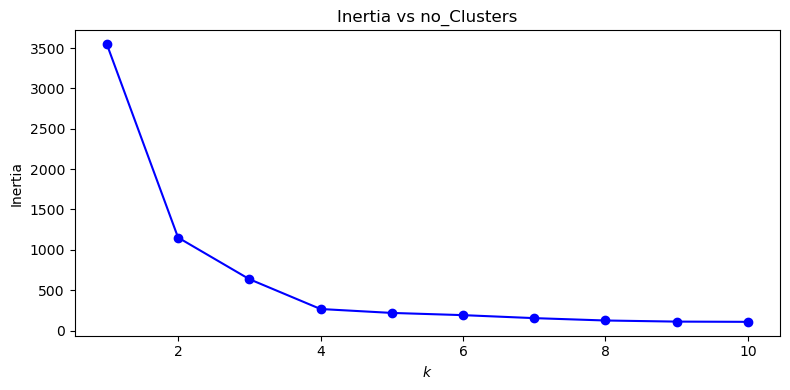

In [22]:
kmeans_per_k = [KMeans(n_clusters=i, random_state=42).fit(X) for i in range(1, 11)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.title("Inertia vs no_Clusters")
save_fig("inertia_vs_k_plot")
plt.show()

Saving figure silhouette_score_vs_k_plot


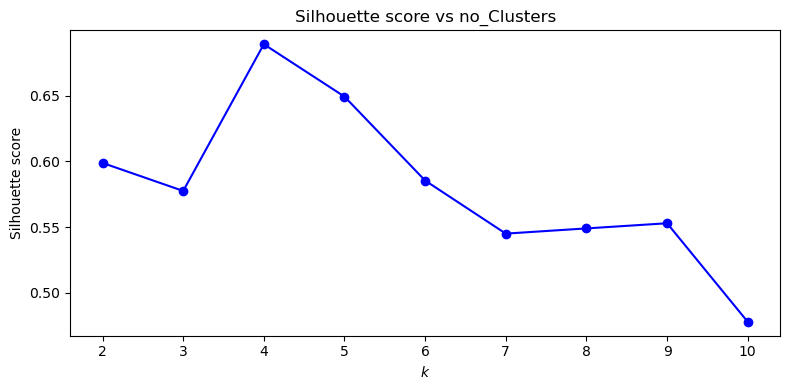

In [23]:
from sklearn.metrics import silhouette_score

sil_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), sil_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs no_Clusters")
save_fig("silhouette_score_vs_k_plot")
plt.show()

**Silhouette Diagram**


Saving figure silhouette_diagram


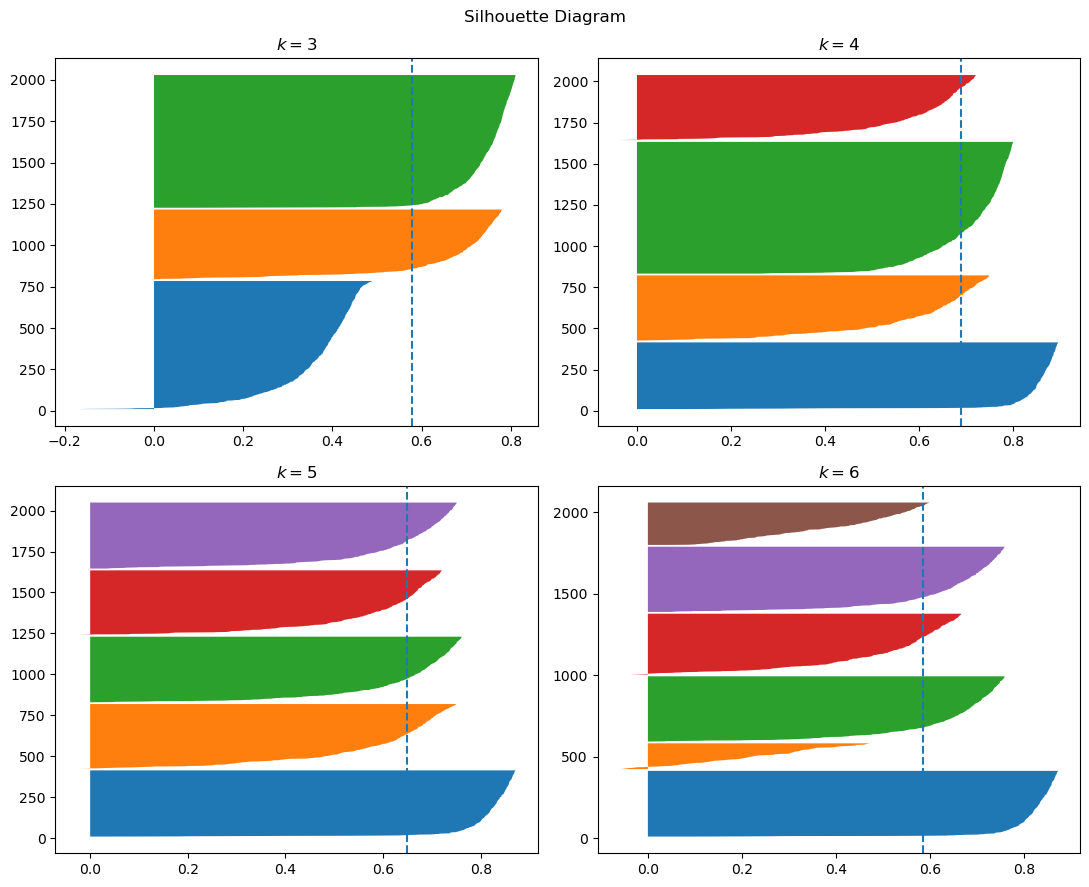

In [24]:
from sklearn.metrics import silhouette_samples

plt.figure(figsize=(11, 9))
for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    labels = kmeans_per_k[k - 1].labels_

    avg_score = silhouette_score(X, labels)
    coeffs = silhouette_samples(X, labels)

    y_lower = 10

    for i in range(k):
        cluster_sil_coeffs = coeffs[labels == i]
        cluster_sil_coeffs.sort()

        size = cluster_sil_coeffs.shape[0]
        y_upper = y_lower + size

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_coeffs)

        y_lower = y_upper + 10

    plt.title(f"$k=${k}")
    plt.axvline(avg_score, linestyle="--")

plt.suptitle("Silhouette Diagram")
save_fig("silhouette_diagram")
plt.show()

### Image Segmentation


In [25]:
# Download the ladybug image

import urllib

images_path = os.path.join(PROJECT_ROOT_DIR, "images", "unsupervised_learning")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "ladybug.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/unsupervised_learning/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))

('.\\images\\unsupervised_learning\\ladybug.png',
 <http.client.HTTPMessage at 0x2405fefec10>)

In [26]:
from matplotlib.image import imread

image = imread(os.path.join("images", "clustering", filename))
image.shape

(533, 800, 3)

In [27]:
image[:1, :1]

array([[[0.09803922, 0.11372549, 0.00784314]]], dtype=float32)

Saving figure color_segmentation


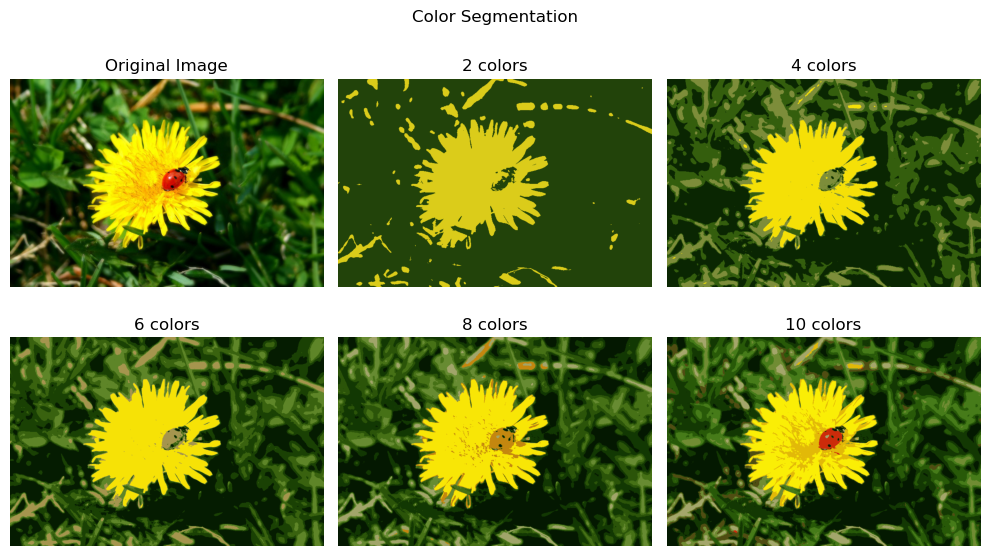

In [28]:
X = image.reshape(-1, 3)

plt.figure(figsize=(10, 6))
plt.subplot(231)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

n_colors = range(2, 11, 2)
for i, n_clusters in enumerate(n_colors):
    kmeans = KMeans(n_clusters=n_clusters).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_img = segmented_img.reshape(image.shape)

    plt.subplot(232 + i)
    plt.imshow(segmented_img)
    plt.title(f"{n_clusters} colors")
    plt.axis("off")

plt.suptitle("Color Segmentation")
save_fig("color_segmentation")
plt.show()

### Preprocessing


In [29]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [30]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits)

log_reg = LogisticRegression(random_state=42, max_iter=1000, solver="saga")
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
log_reg_score = log_reg.score(X_test, y_test)
log_reg_score

0.9622222222222222

In [32]:
pipeline = Pipeline(
    [
        ("kmeans", KMeans(n_clusters=50)),
        ("log_reg", LogisticRegression(max_iter=10000, solver="saga")),
    ]
)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('kmeans', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",50
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with r

In [33]:
pipeline.score(X_test, y_test)

0.96

In [34]:
param_grid = {"kmeans__n_clusters": range(2, 100)}
grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.3s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.3s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.2s
[CV] END ...............................kmeans__n_clusters=5; total time=   0.2s
[CV] END ...............................kmeans__n_clusters=5; total time=   0.2s
[CV] END ...............................kmeans_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kmeans__n_clusters': range(2, 100)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [35]:
grid_clf.best_params_

{'kmeans__n_clusters': 61}

In [36]:
pipeline_score = grid_clf.score(X_test, y_test)
pipeline_score

0.9666666666666667

In [37]:
# Out of the mistakes the old model made, how many did the new model fix
1 - (1 - pipeline_score) / (1 - log_reg_score)

0.1176470588235301

## DBScan


In [38]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [39]:
dbscan.labels_

array([ 0,  1,  1,  2,  1, -1,  2,  2,  1,  1,  2,  2,  3,  2,  1,  3,  3,
        2,  2,  2,  0,  2,  4,  3,  3,  2,  2,  4,  0,  0,  1,  2,  4,  2,
       -1,  2,  0,  2,  2,  3,  0,  3,  0, -1,  2,  3,  0,  2,  0,  0,  7,
        0,  2,  3,  3,  5,  0, -1,  1,  8,  3,  0,  0,  3,  4,  6,  2,  7,
       -1,  2,  5,  1,  4,  1,  3,  1,  0,  3,  2,  3,  2,  6,  6,  1,  3,
        2,  3,  2,  2,  4,  3,  0,  4,  0,  6,  0,  2,  8,  1,  8,  0,  0,
        2,  5,  3,  1,  8,  0,  7,  3,  0,  1,  0,  2,  2,  8,  3,  5,  6,
        3,  2,  0,  0,  3,  3,  3,  0,  8,  3,  3,  3,  2,  3,  0, -1,  2,
        2,  2,  3,  8,  2,  3,  2,  2,  2,  2,  1,  3,  1,  1,  3,  4,  0,
        2,  0, -1,  3,  1,  8,  6,  0,  0,  4,  3, -1,  3,  4,  3,  0,  1,
        0,  0,  3,  3,  3,  3,  6,  1,  2,  7,  3,  0, -1,  2,  0,  0,  0,
       -1,  3,  0,  4,  3,  8,  4,  3, -1,  3,  3,  3,  2,  0,  2,  0,  3,
        2,  2,  4,  2,  2,  5,  1,  8,  3,  4,  2,  1,  2,  0,  3,  3,  8,
        3,  0,  0,  6,  1

In [40]:
print(f"Number of Core instance : {len(dbscan.core_sample_indices_)}")
print(f"\nIndices\n{dbscan.core_sample_indices_}")
print(f"\nCore instances\n{dbscan.components_}")

Number of Core instance : 812

Indices
[  0   1   2   3   4   6   8  10  11  12  13  14  15  16  17  18  19  21
  22  23  25  27  28  29  30  31  32  33  35  36  37  38  40  42  44  45
  46  47  48  49  51  52  53  55  56  58  60  62  63  64  65  66  67  69
  70  71  72  73  74  75  76  78  79  80  81  82  83  84  86  87  88  89
  90  91  92  93  94  95  96  97  98 100 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 120 121 122 123 124 125 126 127 128 130
 131 132 133 137 138 139 140 142 143 144 145 146 147 148 149 150 151 152
 153 154 156 157 158 159 160 161 162 163 165 166 167 168 169 170 171 172
 174 175 176 177 178 179 180 181 183 184 185 186 188 189 190 191 192 193
 194 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 235 237 238 239 240 241 242 243 245 246 247 248 249 251 253 255 256
 257 259 260 261 263 264 265 266 267 268 270 272 273 274 275 276 277 278
 279 280 281

In [41]:
def dbscan_plot(dbscan, X):
    labels = dbscan.labels_
    core_mask = np.zeros_like(labels, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    noise_mask = labels == -1
    border_mask = ~(core_mask | noise_mask)

    cores = X[core_mask]
    borders = X[border_mask]
    noises = X[noise_mask]

    plt.scatter(
        cores[:, 0], cores[:, 1], marker="o", c=labels[core_mask], s=200, cmap="Paired"
    )
    plt.scatter(cores[:, 0], cores[:, 1], marker="*", c=labels[core_mask], label="Core")
    plt.scatter(borders[:, 0], borders[:, 1], marker=".", c="black", label="Border")
    plt.scatter(noises[:, 0], noises[:, 1], marker="x", c="red", label="Noise")

    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.legend(loc="upper right")

Suggested eps ≈ 0.1222
Saving figure k_distance_graph


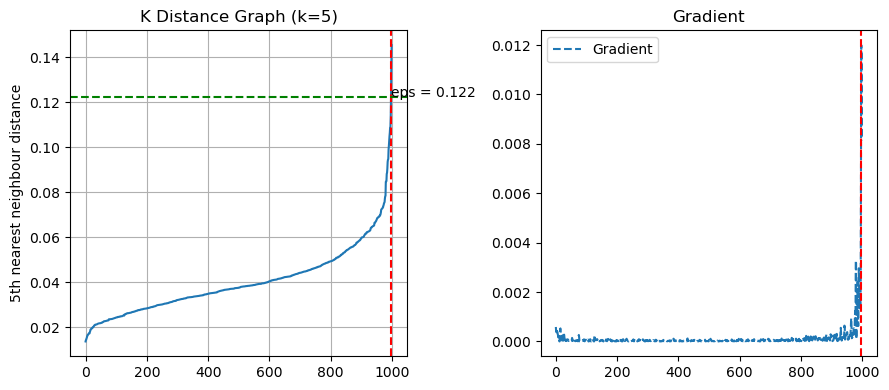

In [42]:
from sklearn.neighbors import NearestNeighbors


def plot_k_distances(X, k):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)

    distances, _ = nn.kneighbors(X)
    k_distances = distances[:, -1]

    k_distances.sort()

    gradients = np.gradient(k_distances)
    elbow_idx = np.argmax(gradients)
    elbow_value = k_distances[elbow_idx]

    plt.subplot(121)
    plt.plot(k_distances)
    plt.axvline(elbow_idx, color="red", linestyle="--")
    plt.axhline(
        elbow_value, color="green", linestyle="--", label=f"eps ≈ {elbow_value:.3f}"
    )
    plt.text(elbow_idx, elbow_value, f"eps = {elbow_value:.3f}")
    plt.ylabel(f"{k}th nearest neighbour distance")
    plt.title(f"K Distance Graph (k={k})")
    plt.grid(True)

    plt.subplot(122)
    plt.plot(gradients, linestyle="--", label="Gradient")
    plt.axvline(elbow_idx, color="red", linestyle="--")
    plt.title("Gradient")

    plt.legend()
    plt.tight_layout()

    print(f"Suggested eps ≈ {elbow_value:.4f}")


plt.figure(figsize=(9, 4))
plot_k_distances(X, k=5)
save_fig("k_distance_graph")
plt.show()

In [43]:
dbscan2 = DBSCAN(eps=0.121, min_samples=4)
dbscan2.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.121
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",4
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Saving figure dbscan_plot


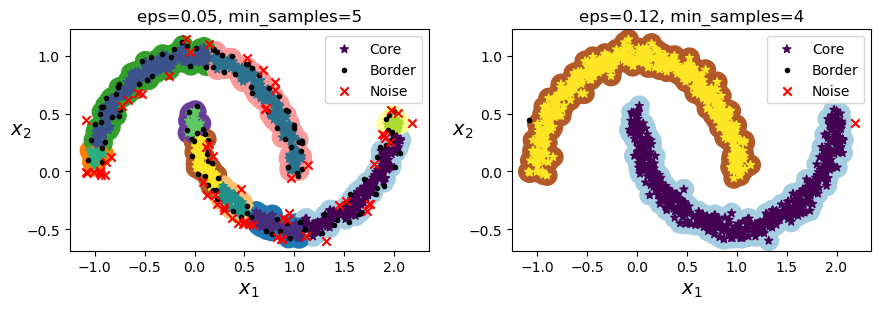

In [44]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
dbscan_plot(dbscan, X)

plt.subplot(122)
dbscan_plot(dbscan2, X)

save_fig("dbscan_plot")
plt.show()

In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=30)

knn.fit(dbscan2.components_, dbscan2.labels_[dbscan2.core_sample_indices_])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",30
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

Saving figure cluster_classification_plot


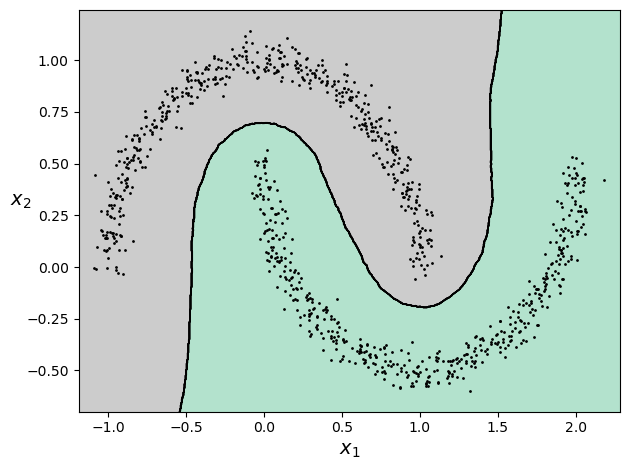

In [48]:
plot_decision_boundary(knn, X, show_centroids=False)
save_fig("cluster_classification_plot")

## Hierarchical clustering


In [49]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [50]:
iris = load_iris()

X = iris.data
y = iris.target

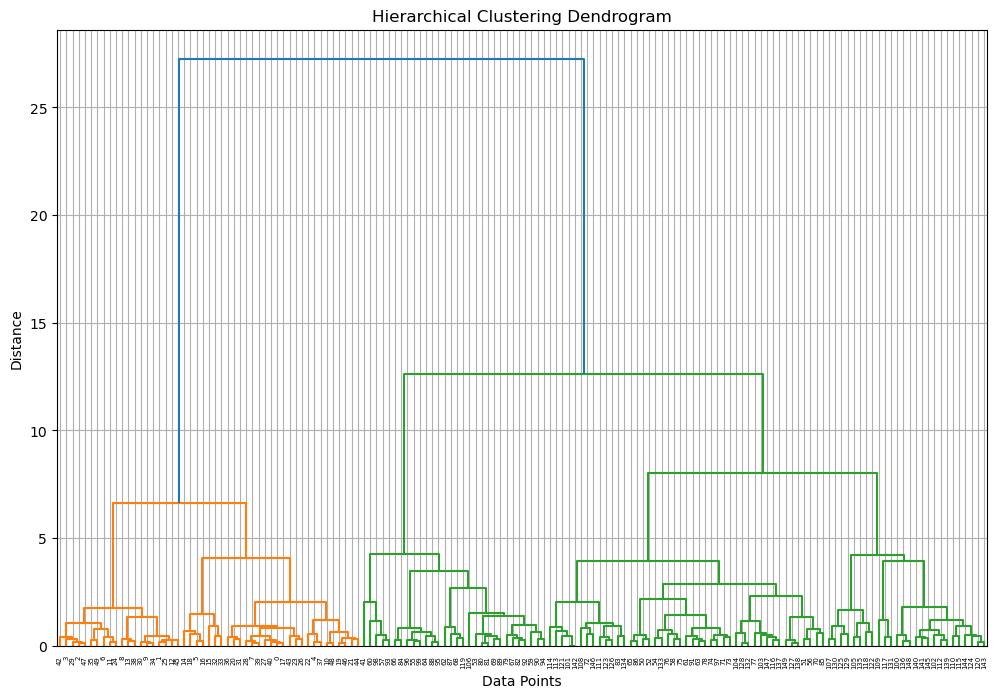

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 8))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

In [52]:
model = AgglomerativeClustering(n_clusters=3, linkage="ward")

clusters = model.fit_predict(X_scaled)

print(clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


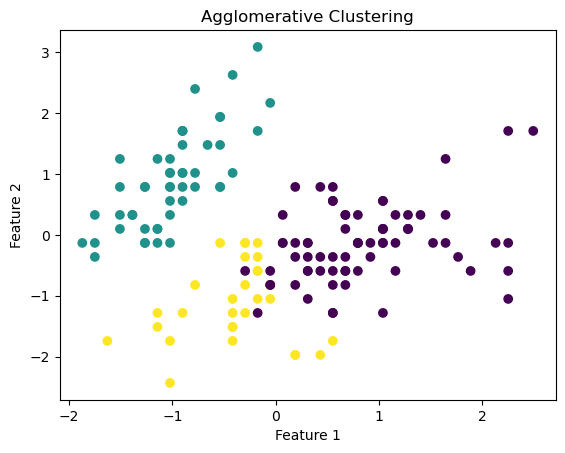

In [53]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("Agglomerative Clustering")

plt.show()

In [54]:
linked

array([[1.01000000e+02, 1.42000000e+02, 0.00000000e+00, 2.00000000e+00],
       [7.00000000e+00, 3.90000000e+01, 1.21167870e-01, 2.00000000e+00],
       [1.00000000e+01, 4.80000000e+01, 1.21167870e-01, 2.00000000e+00],
       [0.00000000e+00, 1.70000000e+01, 1.31632184e-01, 2.00000000e+00],
       [9.00000000e+00, 3.40000000e+01, 1.31632184e-01, 2.00000000e+00],
       [1.28000000e+02, 1.32000000e+02, 1.31632184e-01, 2.00000000e+00],
       [1.27000000e+02, 1.38000000e+02, 1.33836265e-01, 2.00000000e+00],
       [2.00000000e+00, 4.70000000e+01, 1.33836265e-01, 2.00000000e+00],
       [1.90000000e+01, 4.60000000e+01, 1.43378956e-01, 2.00000000e+00],
       [8.00000000e+01, 8.10000000e+01, 1.43378956e-01, 2.00000000e+00],
       [1.00000000e+00, 2.50000000e+01, 1.66143388e-01, 2.00000000e+00],
       [1.20000000e+02, 1.43000000e+02, 1.66143388e-01, 2.00000000e+00],
       [1.10000000e+01, 2.40000000e+01, 1.70512281e-01, 2.00000000e+00],
       [4.00000000e+01, 1.53000000e+02, 1.72216546e

# Review 

In [1]:
from sklearn.datasets import make_moons

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.metrics import silhouette_score

import os



In [2]:
X,y = make_moons(n_samples=100, noise=0.05, random_state=42)


In [3]:
models = [KMeans(n_clusters=i).fit(X) for i in range(2, 8)]
inertias = [model.inertia_ for model in models]

plt.plot(range(2, 8), inertias, marker="o")
plt.ylabel("inertias")
plt.xlabel("no. of clusters")
plt.show()

c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known

NameError: name 'plt' is not defined

c:\Users\USER\.conda\envs\ml-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


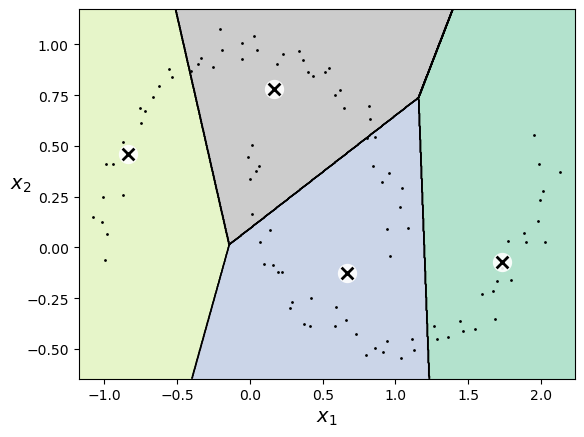

In [ ]:
kmeans = KMeans(n_clusters=4).fit(X)
plot_decision_boundary(kmeans, X)

In [ ]:
silhouette_score(X, kmeans.labels_)

0.4502662385106365

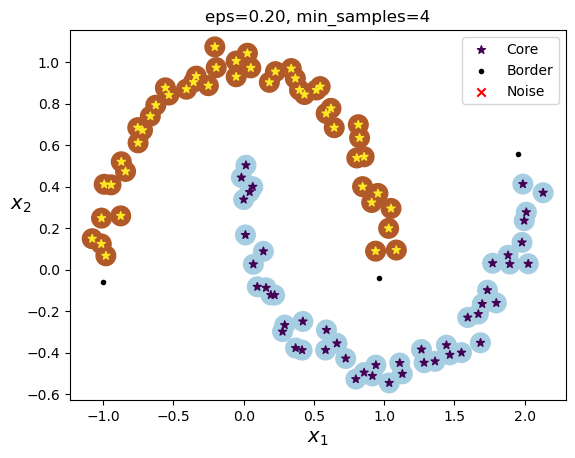

In [ ]:
dbscan = DBSCAN(eps=0.15, min_samples=4)
dbscan.fit(X)

dbscan_plot(dbscan, X)

In [ ]:
silhouette_score(X, dbscan.labels_)

0.3142252578112316

Suggested eps ≈ 0.2849


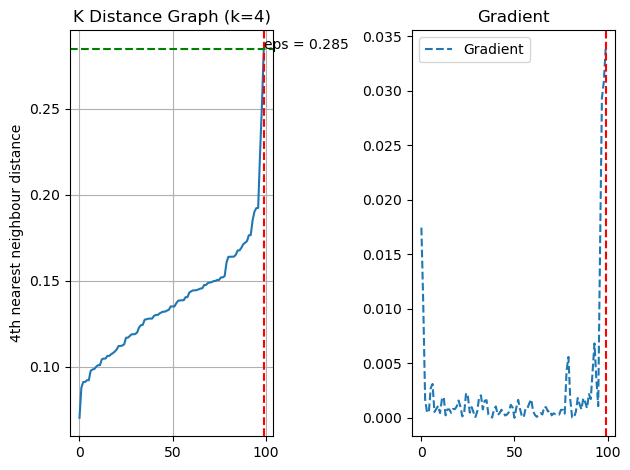

In [ ]:
plot_k_distances(X, 4)

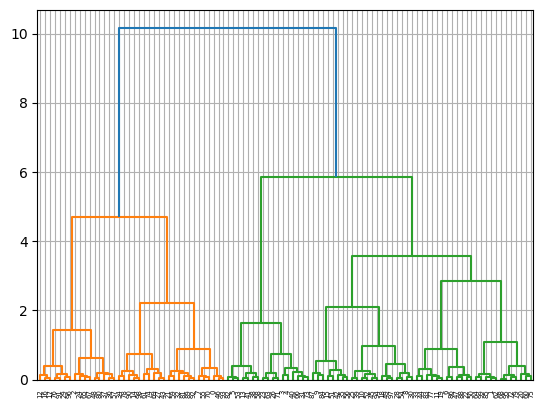

In [ ]:
linked = linkage(X, method='ward')

dendrogram(linked)
plt.grid(True)
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=2, )
hc.fit(X)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


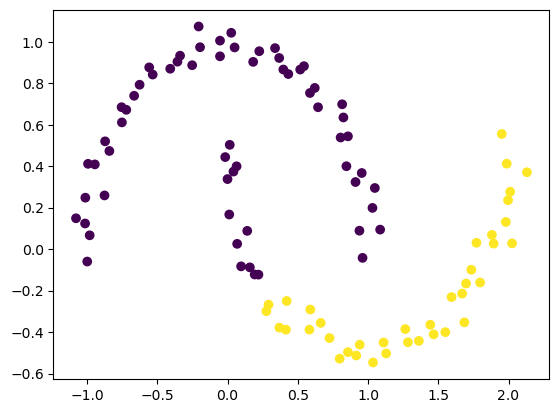

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c = hc.labels_)
plt.show()

In [ ]:
silhouette_score(X, hc.labels_)

0.42242260722592684